# UNIVERSAL Connect-4 data generator (LA + PPO)

This notebook generates **per-move supervised rows** (state_before + action + optional policy probs) from games played by any mix of agents:

- Lookahead vs Lookahead
- PPO vs Lookahead
- Lookahead vs PPO
- PPO vs PPO
- Random can be used as an opponent **but its moves are never recorded**

**Important:** if the *starting player* is Random, the entire game is skipped (random openings are trash labels).


In [1]:
import os
import sys
import random
import time
import secrets
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from C4.connect4_env import Connect4Env
from C4.fast_connect4_lookahead import Connect4Lookahead

from C4.c4_move_data_generator_refactored import (
    generate_dataset,          # universal: LA/Random/PPO combinations
    records_to_dataframe,
    upsert_excel,
)

# PPO modules
import torch
from PPO.actor_critic import ActorCritic

print('Imports OK')
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())


Imports OK
torch: 2.5.1
cuda available: True


## PLAYS

Use the format:

```python
"L3R": {"A": 3, "B": "R", "games": 50}
```

Where `A` / `B` can be:
- `int` depth (Lookahead)
- `'R'` / `'Random'` (uniform random legal move)
- a checkpoint path like `'PPO_Models/PPO_2a.pt'`


In [2]:
def modelName(model):
    return model.split("/")[1].split(".")[0]

In [3]:
#MODEL1 = "PPO_Models/PPO_843.pt"
#MODEL1 = "PPO_Models/PPO_832.pt"
#MODEL1 = "PPO_Models/PPO_909.pt"

MODEL1name = modelName(MODEL1)


PLAYS = {}
startLA = 9 #1
endLA = 13
step = 2
games = 100

for LA in range(startLA, endLA+1, step):
    PLAYS[f"{MODEL1name}_L{LA}"] = {'A': MODEL1, 'B': LA, 'games': games}
    PLAYS[f"L{LA}_{MODEL1name}"] = {'B': MODEL1, 'A': LA, 'games': games}
PLAYS


{'PPO_843_L9': {'A': 'PPO_Models/PPO_843.pt', 'B': 9, 'games': 100},
 'L9_PPO_843': {'B': 'PPO_Models/PPO_843.pt', 'A': 9, 'games': 100},
 'PPO_843_L11': {'A': 'PPO_Models/PPO_843.pt', 'B': 11, 'games': 100},
 'L11_PPO_843': {'B': 'PPO_Models/PPO_843.pt', 'A': 11, 'games': 100},
 'PPO_843_L13': {'A': 'PPO_Models/PPO_843.pt', 'B': 13, 'games': 100},
 'L13_PPO_843': {'B': 'PPO_Models/PPO_843.pt', 'A': 13, 'games': 100}}

In [4]:
DATA_FILE = f'DATA/C4.train_data_ppo_{MODEL1name}.xlsx'  # output Excel
SHEET_NAME = 'Sheet1'
Path(DATA_FILE).parent.mkdir(parents=True, exist_ok=True)


## Generator configuration

- `state_mode='before'` for classic supervised `(state_before, action)`
- `store_policy_probs=True` stores `p0..p6` for non-random movers:
  - Lookahead: uniform among best-scored legal moves
  - PPO: masked softmax probs over legal moves (optionally with temperature)

- `exclude_random_starts=True` skips games where player A is Random (random openings).


In [5]:
CFG = {
    # Lookahead noise (keep 0 for supervised)
    'noiseA': 0.0,
    'noiseB': 0.0,
    'forceLoss': 0.0,

    # Teacher policy extraction for Lookahead
    'teacher_mode': 'scores',   # 'scores' = uniform-among-best; 'fast' = deterministic
    'supervised_min_lookahead_depth': 7,

    # Store state
    'state_mode': 'before',     # 'before' or 'after'

    # Columns
    'store_action': True,
    'store_player': True,
    'store_done': False,
    'store_policy_probs': True,

    # PPO behavior
    'ppo_temperature': 1.0,     # affects stored probs + sampling
    'ppo_action': 'sample',     # 'sample' or 'argmax'

    # Critical: random starts are garbage labels
    'exclude_random_starts': True,
}


In [6]:

BASE = secrets.randbits(64)

records = []
for i, (label, cfg) in enumerate(tqdm(PLAYS.items(), desc="PLAYS")):
    seed_i = (BASE + i) & ((1<<64) - 1)
    records.extend(generate_dataset({label: cfg}, seed=seed_i, CFG=CFG))

df_new   = records_to_dataframe(records)
df_saved = upsert_excel(df_new, DATA_FILE)
print("Saved", len(df_saved), "unique rows")


PLAYS:   0%|          | 0/6 [00:00<?, ?it/s]

Saved 8301 unique rows


In [7]:
df_new[['reward']].describe()
# 14209                                                                                                                                                                                                                               

,reward
count,8301.000000
mean,677.097255
std,2320.996312
min,-975.600000
25%,15.160000
50%,33.150000
75%,97.212500
max,10000.000000


In [8]:
df_saved[['reward']].describe()

,reward
count,8301.000000
mean,677.097255
std,2320.996312
min,-975.600000
25%,15.160000
50%,33.150000
75%,97.212500
max,10000.000000


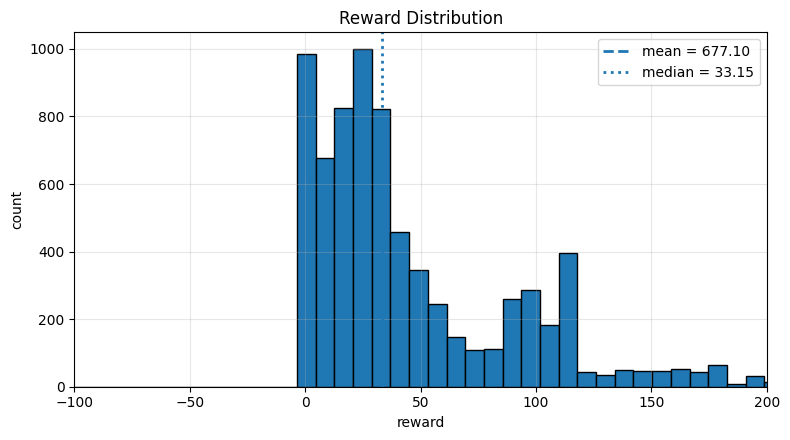

In [9]:
# Quick reward histogram

r = df_saved['reward'].astype(float).dropna()
fig, ax = plt.subplots(figsize=(8,4.5))
bins = np.arange(r.min()-0.5, r.max()+1.5, 1) if np.allclose(r, r.round()) else 'auto'
ax.hist(r, bins=bins, edgecolor='black')
ax.axvline(r.mean(), ls='--', lw=2, label=f"mean = {r.mean():.2f}")
ax.axvline(r.median(), ls=':', lw=2, label=f"median = {r.median():.2f}")
ax.set(title='Reward Distribution', xlabel='reward', ylabel='count')
ax.grid(True, alpha=0.3)
plt.xlim(-100, 200)
ax.legend()
fig.tight_layout()
